In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

plt.style.use("ggplot")

In [12]:
np.random.seed(42)

dates = pd.date_range(start="2022-01-01", periods=730)  # 2 YEARS DATA

trend = np.linspace(200, 600, 730)
seasonality = 80 * np.sin(np.linspace(0, 25, 730))
noise = np.random.normal(0, 40, 730)

sales = trend + seasonality + noise

df = pd.DataFrame({
    "Date": dates,
    "Sales": sales.round(0),
    "Region": np.random.choice(["North", "South", "East", "West"], 730),
    "Category": np.random.choice(["Tech", "Furniture", "Office"], 730)
})

df.to_csv("sales_data.csv", index=False)

df.head()

,Date,Sales,Region,Category
0,2022-01-01,220.0,East,Furniture
1,2022-01-02,198.0,South,Tech
2,2022-01-03,232.0,South,Office
3,2022-01-04,271.0,West,Office
4,2022-01-05,204.0,North,Tech


In [13]:
df = pd.read_csv("sales_data.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

df.head()

,Sales,Region,Category
Date,,,
2022-01-01,220.0,East,Furniture
2022-01-02,198.0,South,Tech
2022-01-03,232.0,South,Office
2022-01-04,271.0,West,Office
2022-01-05,204.0,North,Tech


In [14]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate range:", df.index.min(), "to", df.index.max())

Missing values:
 Sales       0
Region      0
Category    0
dtype: int64

Duplicate rows: 56

Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00


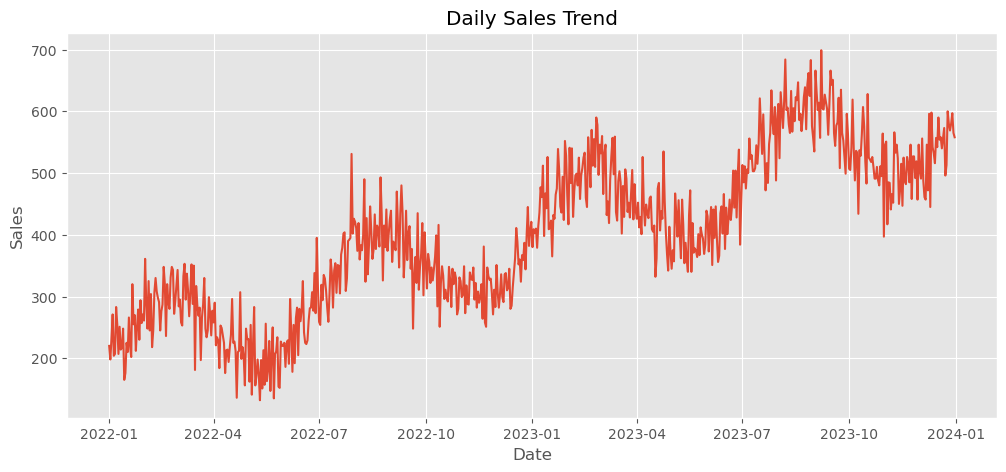

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df['Sales'])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

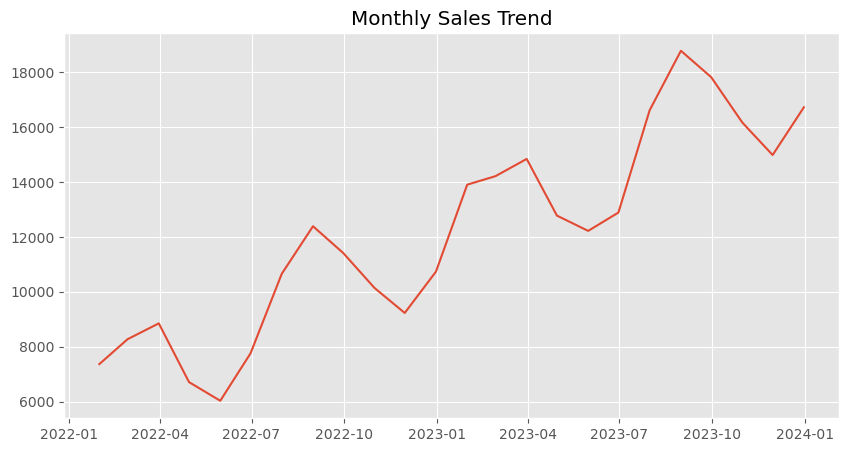

In [16]:
monthly_sales = df['Sales'].resample('M').sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.show()

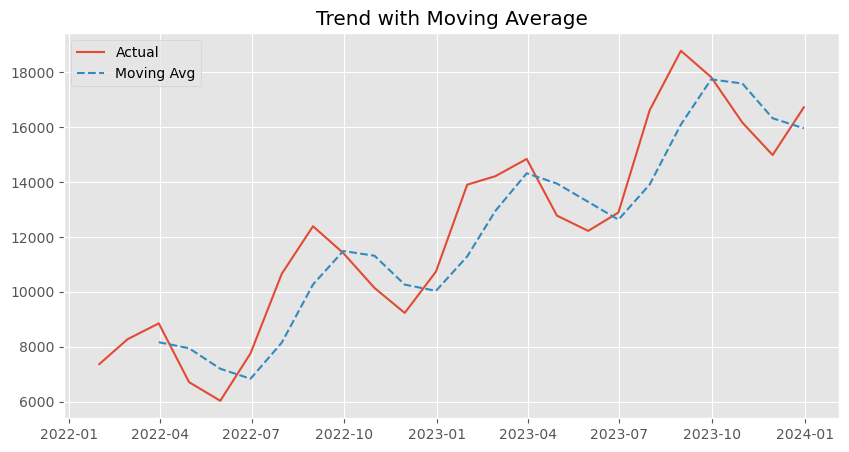

In [17]:
rolling_mean = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label="Actual")
plt.plot(rolling_mean, linestyle="--", label="Moving Avg")
plt.legend()
plt.title("Trend with Moving Average")
plt.show()

In [18]:
train = df['Sales'][:-30]
test = df['Sales'][-30:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 700
Test size: 30


In [19]:
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\anees\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\anees\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\anees\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  700
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3615.374
Date:                Mon, 20 Apr 2026   AIC                           7240.749
Time:                        13:29:29   BIC                           7263.497
Sample:                    01-01-2022   HQIC                          7249.543
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8879      0.146     -6.094      0.000      -1.174      -0.602
ar.L2         -0.1063      0.048     -2.204      0.028      -0.201      -0.012
ma.L1          0.0418      0.141      0.297      0.7

In [20]:
forecast = model_fit.forecast(steps=30)

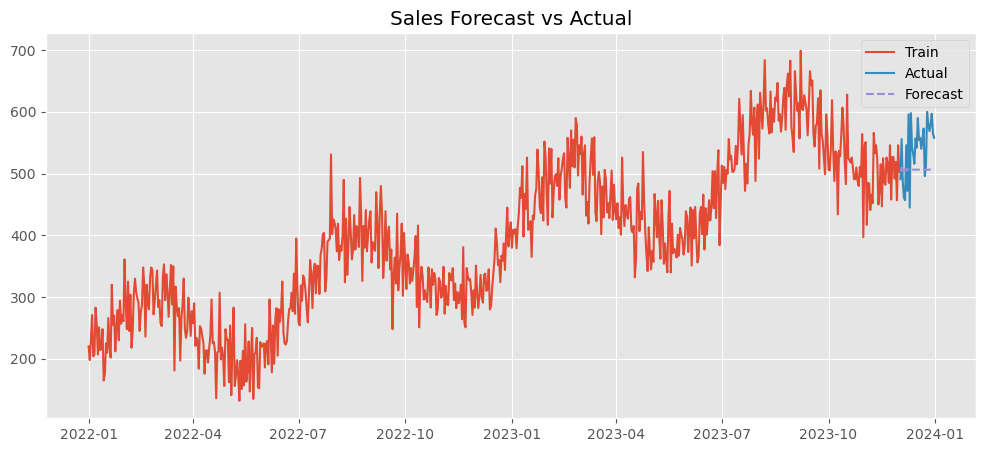

In [22]:
 plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast", linestyle="--")

plt.legend()
plt.title("Sales Forecast vs Actual")
plt.show()

In [23]:
mae = mean_absolute_error(test, forecast)

print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 49.82


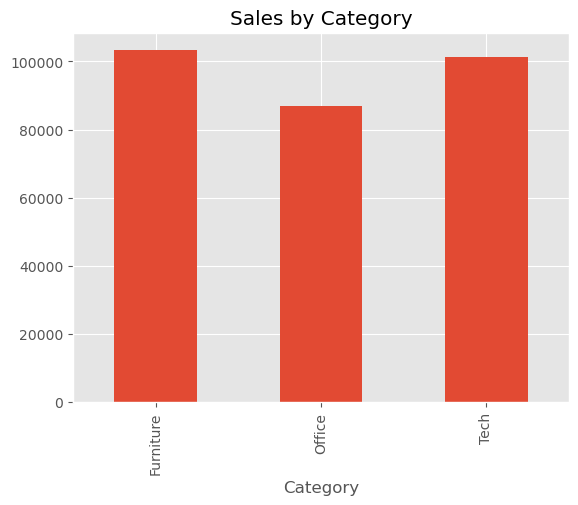

In [24]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind='bar', title="Sales by Category")
plt.show()

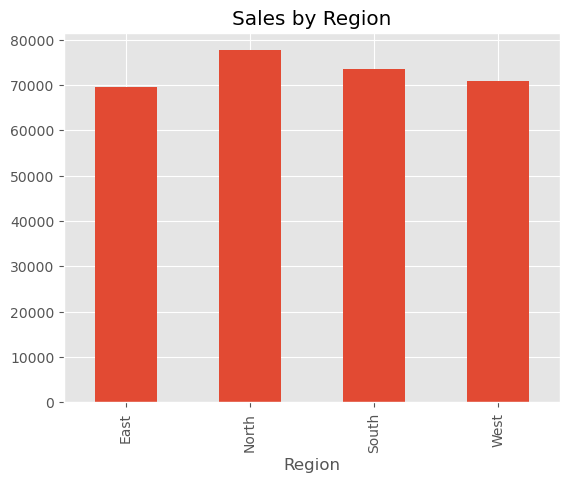

In [25]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind='bar', title="Sales by Region")
plt.show()

In [26]:
print(" BUSINESS INSIGHTS\n")

print(f"Total Sales: {round(df['Sales'].sum(),2)}")
print(f"Top Category: {category_sales.idxmax()}")
print(f"Top Region: {region_sales.idxmax()}")
print(f"Forecast Error (MAE): {round(mae,2)}")

print("\nInsights:")
print("- Sales show upward trend with seasonal patterns.")
print("- Forecast helps in planning inventory and demand.")
print("- Certain categories contribute more to revenue.")
print("- Data-driven decisions can improve business growth.")

📊 BUSINESS INSIGHTS

Total Sales: 291606.0
Top Category: Furniture
Top Region: North
Forecast Error (MAE): 49.82

Insights:
- Sales show upward trend with seasonal patterns.
- Forecast helps in planning inventory and demand.
- Certain categories contribute more to revenue.
- Data-driven decisions can improve business growth.


In [27]:
monthly_sales.to_csv("monthly_sales.csv")
forecast.to_csv("sales_forecast.csv")

print("Files exported successfully!")

Files exported successfully!
